In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)

t = torch.linspace(0, 20, 500)

data = torch.sin(t) + 0.1 * torch.randn(500)

print("Data shape:", data.shape)

Data shape: torch.Size([500])


In [2]:
seq_len = 20

X, Y = [], []

for i in range(len(data) - seq_len):
    X.append(data[i:i+seq_len])
    Y.append(data[i+seq_len])

X = torch.stack(X).unsqueeze(1)
Y = torch.stack(Y).unsqueeze(1)

print("X:", X.shape)
print("Y:", Y.shape)

X: torch.Size([480, 1, 20])
Y: torch.Size([480, 1])


In [3]:
class CausalConv(nn.Module):

    def __init__(self, in_c, out_c, kernel, dilation):
        super().__init__()

        self.padding = (kernel - 1) * dilation

        self.conv = nn.Conv1d(
            in_c,
            out_c,
            kernel,
            dilation=dilation,
            padding=self.padding
        )

    def forward(self, x):

        x = self.conv(x)

        return x[:, :, :-self.padding]

In [4]:
class TCN(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            CausalConv(1, 16, 3, 1),
            nn.ReLU(),

            CausalConv(16, 16, 3, 2),
            nn.ReLU(),

            CausalConv(16, 16, 3, 4),
            nn.ReLU(),

            CausalConv(16, 1, 3, 8)
        )

    def forward(self, x):
        return self.net(x)[:, :, -1]

In [5]:
model = TCN()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

loss_fn = nn.MSELoss()

losses = []

for epoch in range(50):

    optimizer.zero_grad()

    pred = model(X)

    loss = loss_fn(pred, Y)

    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if epoch % 10 == 0:
        print(
            f"Epoch {epoch}, Loss: {loss.item():.4f}"
        )

Epoch 0, Loss: 0.5234
Epoch 10, Loss: 0.4889
Epoch 20, Loss: 0.4544
Epoch 30, Loss: 0.3884
Epoch 40, Loss: 0.2836


In [6]:
with torch.no_grad():
    predictions = model(X)

print("Prediction shape:", predictions.shape)

Prediction shape: torch.Size([480, 1])


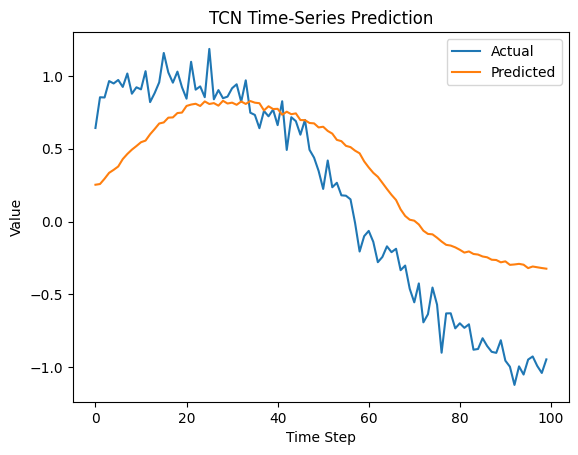

In [7]:
plt.plot(Y[:100].numpy(), label="Actual")
plt.plot(predictions[:100].numpy(), label="Predicted")

plt.title("TCN Time-Series Prediction")
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.legend()
plt.show()

In [8]:
print("TCN completed successfully.")
print("Dilations used: 1, 2, 4, 8")
print("Causal convolutions prevent future information leakage.")

TCN completed successfully.
Dilations used: 1, 2, 4, 8
Causal convolutions prevent future information leakage.
